In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False) 

X, y = mnist.data, mnist.target
X_train, y_train = X[:2000], y[:2000]

In [5]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()

In [7]:
from cross_val import cross_val_predict
y_train_knn_pred_my = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

from sklearn.model_selection import cross_val_predict
y_train_knn_pred_org = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [10]:
print(y_train_knn_pred_my[100])
print(y_train_knn_pred_org[100])

print(np.unique(y_train))

[False  True]
[False  True]
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [11]:
from class_score_funcs import f1_score
print(f1_score(y_multilabel, y_train_knn_pred_org, average="macro"))

from sklearn.metrics import f1_score
print(f1_score(y_multilabel, y_train_knn_pred_org, average="macro"))

0.9176605556691428
0.9176605556691428


In [13]:
from importlib import reload
import class_score_funcs
reload(class_score_funcs)
from class_score_funcs import f1_score
print(f1_score(y_multilabel, y_train_knn_pred_org, average="micro"))

from sklearn.metrics import f1_score
print(f1_score(y_multilabel, y_train_knn_pred_org, average="micro"))

0.921456515197111
0.921456515197111


Test ClassifierChain

In [17]:
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

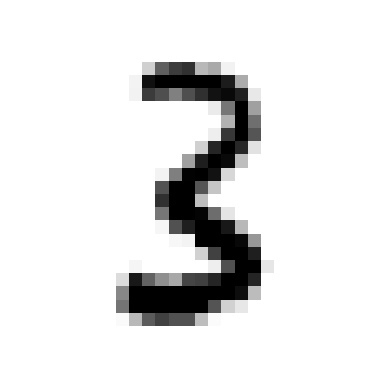

In [19]:
some_digit = X[50000]
plot_digit(some_digit)

In [35]:
from sklearn.svm import SVC
svc_model = SVC(random_state=42)

import classifier_chain
reload(classifier_chain)
from classifier_chain import ClassifierChain
my_chain_clf = ClassifierChain(svc_model, cv=3, random_state=42, chain_method='decision_function')
my_chain_clf.fit(X_train, y_multilabel)

from sklearn.multioutput import ClassifierChain
org_chain_clf = ClassifierChain(svc_model, cv=3, random_state=42, chain_method='decision_function')
org_chain_clf.fit(X_train, y_multilabel)

,estimator,SVC(random_state=42)
,order,None
,cv,3
,chain_method,'decision_function'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [36]:
print(my_chain_clf.predict([some_digit]))
print(org_chain_clf.predict([some_digit]))

print(my_chain_clf.decision_function([some_digit]))
print(org_chain_clf.decision_function([some_digit]))

[[0. 1.]]
[[0. 1.]]
[[-2.24891828  0.61282941]]
[[-2.24891828  0.61282941]]


In [33]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(random_state=42)

import classifier_chain
reload(classifier_chain)
from classifier_chain import ClassifierChain
my_chain_clf = ClassifierChain(forest, cv=3, random_state=42, chain_method='predict_proba')
my_chain_clf.fit(X_train, y_multilabel)

from sklearn.multioutput import ClassifierChain
org_chain_clf = ClassifierChain(forest, cv=3, random_state=42, chain_method='predict_proba')
org_chain_clf.fit(X_train, y_multilabel)

,estimator,RandomForestC...ndom_state=42)
,order,None
,cv,3
,chain_method,'predict_proba'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [34]:
print(my_chain_clf.predict([some_digit]))
print(org_chain_clf.predict([some_digit]))

print(my_chain_clf.predict_proba([some_digit]))
print(org_chain_clf.predict_proba([some_digit]))

[[0. 1.]]
[[0. 1.]]
[[0.08 0.84]]
[[0.08 0.83]]
